In [12]:
# ==========================================
# CONFIGURAÇÕES INICIAIS
# ==========================================

import os
import cv2
import numpy as np
import pandas as pd

from google.colab import drive
from google.colab.patches import cv2_imshow

# Monta o Google Drive
drive.mount('/content/drive')

# Caminho da pasta
PASTA = '/content/drive/My Drive/Visao/'

# Nome da imagem
ARQUIVO = 'entrada.jpeg'

# Caminho completo
CAMINHO_IMAGEM = os.path.join(PASTA, ARQUIVO)

# Lista arquivos da pasta
print(os.listdir(PASTA))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['entrada.jpeg']


Largura : 651px
Altura  : 447px
Canais  : 3


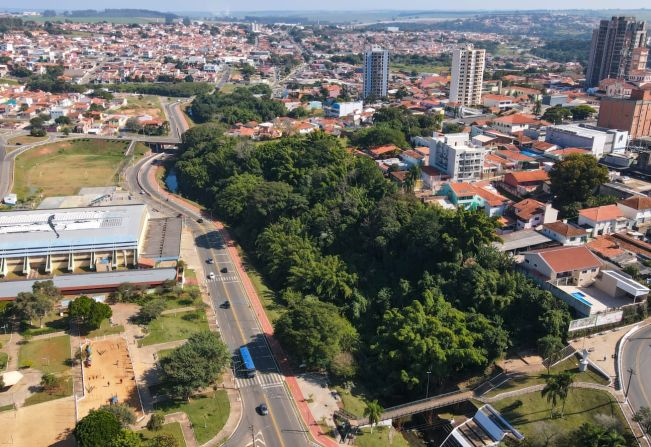

In [13]:
# ==========================================
# CARREGAMENTO DA IMAGEM
# ==========================================

imagem = cv2.imread(CAMINHO_IMAGEM)

# Verificação
if imagem is None:
    print("Erro ao carregar a imagem.")
else:
    altura, largura, canais = imagem.shape

    print(f"Largura : {largura}px")
    print(f"Altura  : {altura}px")
    print(f"Canais  : {canais}")

    cv2_imshow(imagem)

    # Salva cópia
    cv2.imwrite(PASTA + 'saida.jpg', imagem)

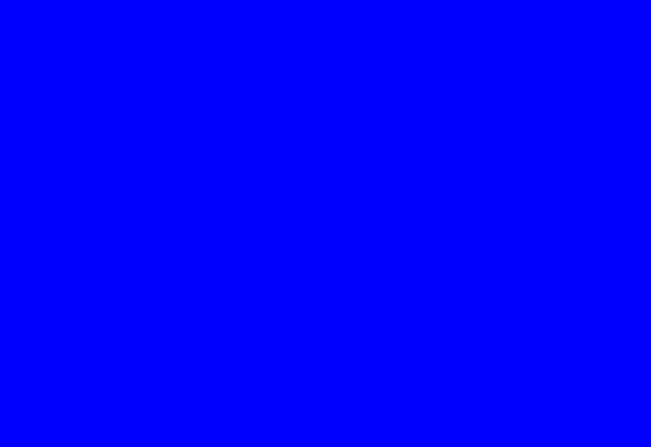

In [14]:
# ==========================================
# ALTERANDO TODOS OS PIXELS
# ==========================================

imagem = cv2.imread(CAMINHO_IMAGEM)

if imagem is not None:

    # Azul em BGR
    imagem[:] = (255, 0, 0)

    cv2_imshow(imagem)

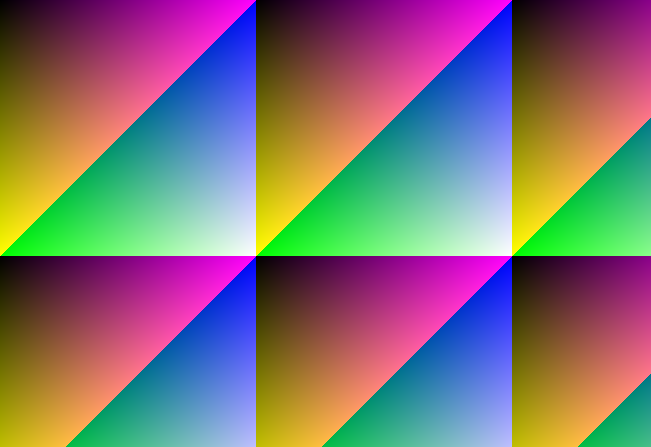

In [15]:
# ==========================================
# PADRÃO DE CORES
# ==========================================

imagem = cv2.imread(CAMINHO_IMAGEM)

if imagem is not None:

    for y in range(imagem.shape[0]):
        for x in range(imagem.shape[1]):

            imagem[y, x] = (
                x % 256,
                y % 256,
                (x + y) % 256
            )

    cv2_imshow(imagem)

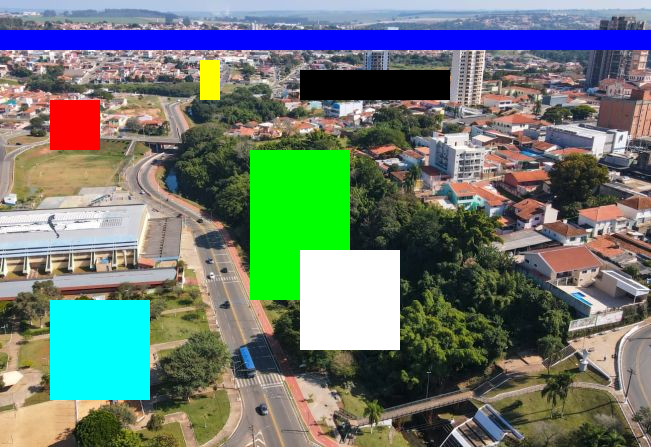

In [16]:
# ==========================================
# BLOCOS COLORIDOS
# ==========================================

imagem = cv2.imread(CAMINHO_IMAGEM)

if imagem is not None:

    # Azul
    imagem[30:50, :] = (255, 0, 0)

    # Vermelho
    imagem[100:150, 50:100] = (0, 0, 255)

    # Amarelo
    imagem[60:100, 200:220] = (0, 255, 255)

    # Verde
    imagem[150:300, 250:350] = (0, 255, 0)

    # Ciano
    imagem[300:400, 50:150] = (255, 255, 0)

    # Branco
    imagem[250:350, 300:400] = (255, 255, 255)

    # Preto
    imagem[70:100, 300:450] = (0, 0, 0)

    cv2_imshow(imagem)

    cv2.imwrite(PASTA + 'alterada.jpg', imagem)

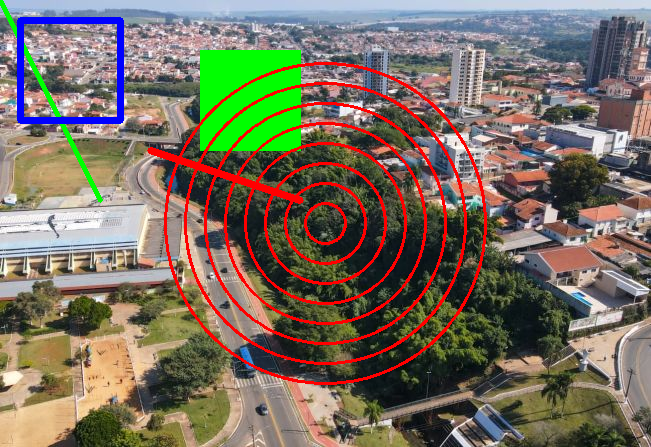

In [17]:
# ==========================================
# FORMAS GEOMÉTRICAS
# ==========================================

imagem = cv2.imread(CAMINHO_IMAGEM)

if imagem is not None:

    vermelho = (0, 0, 255)
    verde = (0, 255, 0)
    azul = (255, 0, 0)

    # Linha
    cv2.line(imagem, (0, 0), (100, 200), verde, 3)

    # Linha vermelha
    cv2.line(imagem, (300, 200), (150, 150), vermelho, 5)

    # Retângulo
    cv2.rectangle(imagem, (20, 20), (120, 120), azul, 5)

    # Retângulo preenchido
    cv2.rectangle(imagem, (200, 50), (300, 150), verde, -1)

    # Círculos
    centro = (imagem.shape[1] // 2, imagem.shape[0] // 2)

    for raio in range(20, 180, 20):
        cv2.circle(imagem, centro, raio, vermelho, 2)

    cv2_imshow(imagem)

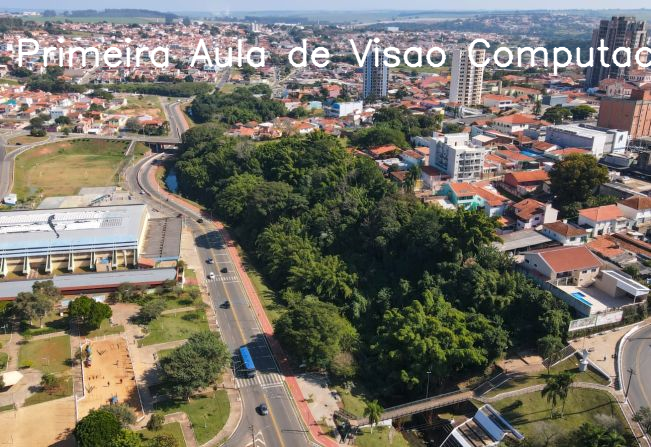

In [18]:
# ==========================================
# TEXTO NA IMAGEM
# ==========================================

imagem = cv2.imread(CAMINHO_IMAGEM)

if imagem is not None:

    fonte = cv2.FONT_HERSHEY_SIMPLEX

    cv2.putText(
        imagem,
        'Primeira Aula de Visao Computacional',
        (15, 65),
        fonte,
        1.2,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

    cv2_imshow(imagem)

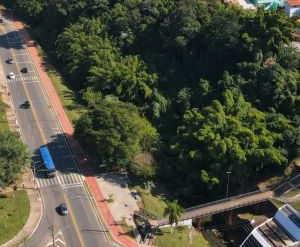

In [19]:
# ==========================================
# RECORTE DA IMAGEM
# ==========================================

imagem = cv2.imread(CAMINHO_IMAGEM)

if imagem is not None:

    recorte = imagem[200:500, 200:500]

    cv2_imshow(recorte)

    cv2.imwrite(PASTA + 'recorte.jpg', recorte)

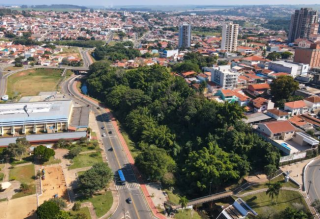

In [20]:
# ==========================================
# REDIMENSIONAMENTO
# ==========================================

imagem = cv2.imread(CAMINHO_IMAGEM)

if imagem is not None:

    largura_original = imagem.shape[1]
    altura_original = imagem.shape[0]

    nova_largura = 320

    proporcao = altura_original / largura_original

    nova_altura = int(nova_largura * proporcao)

    nova_imagem = cv2.resize(
        imagem,
        (nova_largura, nova_altura),
        interpolation=cv2.INTER_AREA
    )

    cv2_imshow(nova_imagem)

Original


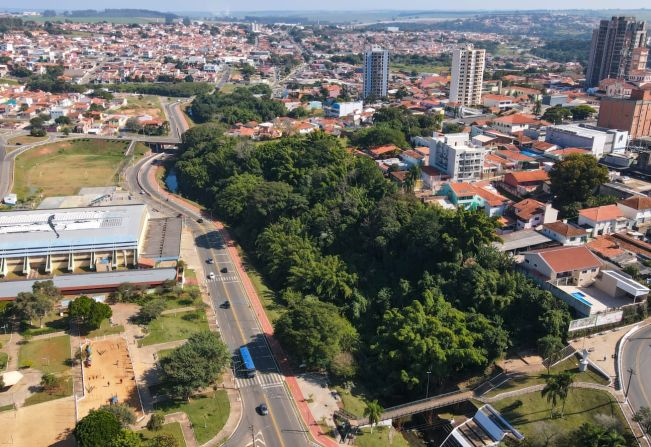

Horizontal


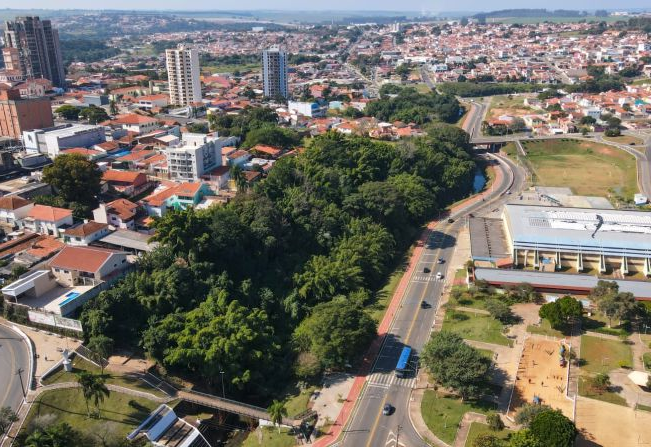

Vertical


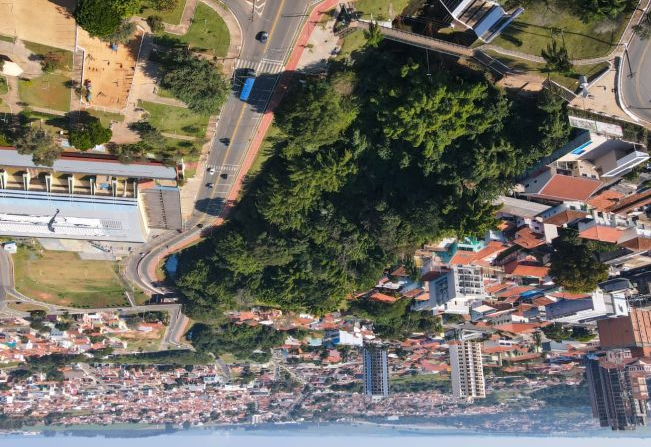

Horizontal + Vertical


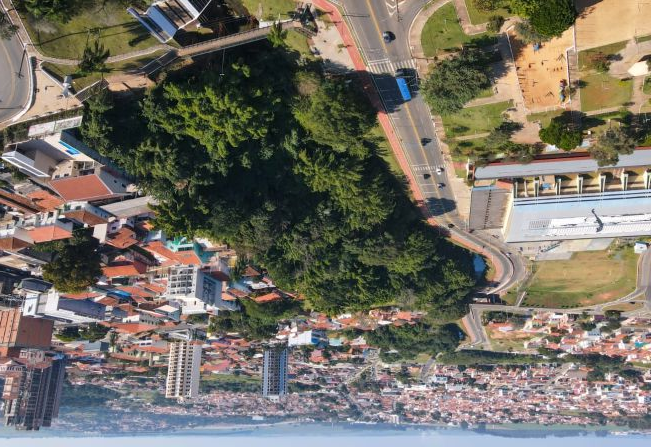

In [21]:
# ==========================================
# FLIP DA IMAGEM
# ==========================================

imagem = cv2.imread(CAMINHO_IMAGEM)

if imagem is not None:

    # Horizontal
    flip_h = cv2.flip(imagem, 1)

    # Vertical
    flip_v = cv2.flip(imagem, 0)

    # Ambos
    flip_hv = cv2.flip(imagem, -1)

    print("Original")
    cv2_imshow(imagem)

    print("Horizontal")
    cv2_imshow(flip_h)

    print("Vertical")
    cv2_imshow(flip_v)

    print("Horizontal + Vertical")
    cv2_imshow(flip_hv)

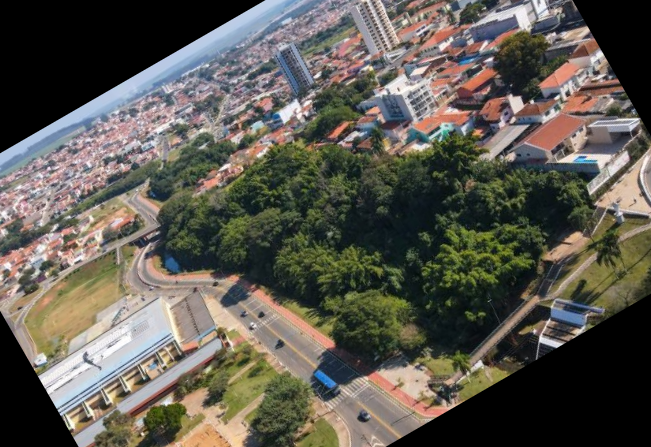

In [22]:
# ==========================================
# ROTAÇÃO
# ==========================================

imagem = cv2.imread(CAMINHO_IMAGEM)

if imagem is not None:

    altura, largura = imagem.shape[:2]

    centro = (largura // 2, altura // 2)

    matriz_rotacao = cv2.getRotationMatrix2D(
        centro,
        30,
        1.0
    )

    imagem_rotacionada = cv2.warpAffine(
        imagem,
        matriz_rotacao,
        (largura, altura)
    )

    cv2_imshow(imagem_rotacionada)